# **Base de Dados Câncer de Mama Wisconsin**

Notebook de análise exploratória e classificação binária da base WDBC.

**Objetivo:** identificar tumores benignos (0) e malignos (1) a partir de
características morfológicas de núcleos celulares obtidas por FNA (*Fine Needle Aspiration*).

**Estrutura do notebook:**
1. Importações e configurações globais
2. Funções auxiliares para gráficos e métricas
3. Carregamento e preparação da base de dados
4. Análise exploratória (EDA)
5. Árvore de Decisão — baseline
6. Regressão Logística
7. KNN
8. Random Forest
9. SVM
10. Visualização de estrutura: UMAP e PCA
11. Interpretabilidade do modelo com SHAP

## **1. Configuração Inicial**

In [1]:
# --- Instalação de dependências externas (executar apenas uma vez por ambiente) ---
%pip install plotly Pillow matplotlib seaborn pandas kagglehub scikit-learn tensorflow yellowbrick umap-learn shap --upgrade -q

Note: you may need to restart the kernel to use updated packages.


In [8]:
# --- Bibliotecas padrão e de dados ---
import pickle
import os

import numpy as np
import pandas as pd
from IPython.display import display

# --- Visualização ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Acesso à base de dados (Kaggle Hub) ---
import kagglehub

# --- Pré-processamento e divisão de dados ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Modelos de Machine Learning ---
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# --- Métricas de avaliação ---
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
)

# --- Redução de dimensionalidade não-linear ---
import umap

# --- Interpretabilidade do modelo ---
import shap

# --- Configurações visuais globais ---
sns.set_theme(style='whitegrid', context='notebook')

# Semente fixa: garante reprodutibilidade em todo o notebook
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Funções Auxiliares para Gráficos e Métricas

In [5]:
def plot_roc_pr(y_true, y_prob, titulo_prefixo=''):
    """
    Plota as curvas ROC e PR (Precisão-Revocação) lado a lado.

    Parâmetros
    ----------
    y_true        : array-like — rótulos reais (0 ou 1)
    y_prob        : array-like — probabilidades previstas para a classe positiva
    titulo_prefixo: str        — prefixo opcional para o título dos gráficos
    """
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Curva ROC
    axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
    axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Aleatório')
    axes[0].set(
        title=f'{titulo_prefixo}Curva ROC',
        xlabel='Falso Positivo (1 - Especificidade)',
        ylabel='Verdadeiro Positivo (Sensibilidade)',
    )
    axes[0].legend(loc='lower right')

    # Curva Precisão-Revocação
    axes[1].plot(rec, prec, color='darkorange', label=f'PR-AUC = {pr_auc:.3f}')
    axes[1].set(
        title=f'{titulo_prefixo}Curva Precisão-Revocação',
        xlabel='Revocação',
        ylabel='Precisão',
    )
    axes[1].legend(loc='lower left')

    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, labels=('Benigno', 'Maligno'), titulo='Matriz de Confusão'):
    """
    Exibe a Matriz de Confusão como heatmap anotado.

    Parâmetros
    ----------
    y_true : array-like — rótulos reais
    y_pred : array-like — rótulos previstos
    labels : tuple     — nomes das classes (negativa, positiva)
    titulo : str       — título do gráfico
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=[f'Real {labels[0]}', f'Real {labels[1]}'],
        columns=[f'Pred. {labels[0]}', f'Pred. {labels[1]}'],
    )
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(titulo)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def compute_stats(y_true, y_pred, y_prob):
    """
    Calcula métricas consolidadas de classificação binária.

    Retorna um dict com: Acurácia, Sensibilidade, Especificidade, F1, ROC-AUC e PR-AUC.

    Parâmetros
    ----------
    y_true : array-like — rótulos reais
    y_pred : array-like — rótulos previstos
    y_prob : array-like — probabilidades para a classe positiva
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc  = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else float('nan')   # Recall da classe positiva
    spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')   # Recall da classe negativa
    f1   = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else float('nan')
    roc  = roc_auc_score(y_true, y_prob)
    pr   = average_precision_score(y_true, y_prob)

    return {
        'Accuracy'             : acc,
        'Sensitivity (Recall+)': sens,
        'Specificity (Recall-)': spec,
        'F1'                   : f1,
        'ROC-AUC'              : roc,
        'PR-AUC'               : pr,
    }

## 3. Carregamento e Preparação da Base de Dados

In [10]:
# --- Download da base de dados via Kaggle Hub ---
path = kagglehub.dataset_download('uciml/breast-cancer-wisconsin-data')
wisconsin_base = pd.read_csv(path + '/data.csv')

# --- Limpeza de colunas não preditivas ---
# 'id': identificador do paciente (sem valor preditivo)
# 'Unnamed: 32': coluna vazia gerada na exportação do CSV
wisconsin_base = wisconsin_base.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# --- Codificação do rótulo: 'B' (Benigno) → 0 | 'M' (Maligno) → 1 ---
wisconsin_base['diagnosis'] = wisconsin_base['diagnosis'].map({'B': 0, 'M': 1})

# --- Separação entre atributos (X) e variável alvo (y) ---
X = wisconsin_base.drop(columns=['diagnosis'])
y = wisconsin_base['diagnosis']

feature_names = X.columns.tolist()
target_names  = ['Benigno', 'Maligno']   # índice 0 = Benigno, 1 = Maligno

print(f'Dimensões de X: {X.shape}')
print(f'Distribuição de classes:\n{y.value_counts().rename({0: "Benigno", 1: "Maligno"})}')

# --- Split estratificado (75 % treino | 25 % teste) ---
# stratify=y: mantém a proporção original de classes em ambos os conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# --- Padronização Z-score (ajustada apenas no treino para evitar data leakage) ---
# Necessária para: Regressão Logística, SVM, PCA, UMAP
scaler       = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_scaled_all   = scaler.transform(X)   # Base completa — usada nas visualizações e SHAP

# --- Serialização dos conjuntos em disco (evita reprocessar nas execuções seguintes) ---

# Define o caminho para a pasta 'data' (voltando um nível a partir de 'notebooks')
caminho_pasta = '../data'
caminho_arquivo = f'{caminho_pasta}/wisconsin.pkl'

# Cria a pasta 'data' automaticamente caso ela não exista
os.makedirs(caminho_pasta, exist_ok=True)


with open(caminho_arquivo, mode='wb') as f:
    pickle.dump([X_train_scaled, y_train, X_test_scaled, y_test], f)
print(f'Arquivo salvo com sucesso em: {caminho_arquivo}')

print(f'\nConjuntos criados  →  Treino: {X_train.shape} | Teste: {X_test.shape}')

Dimensões de X: (569, 30)
Distribuição de classes:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64
Arquivo salvo com sucesso em: ../data/wisconsin.pkl

Conjuntos criados  →  Treino: (426, 30) | Teste: (143, 30)


## 4. Análise Exploratória dos Dados (EDA)

### 4.1 Estatísticas Descritivas

In [22]:
# Visão geral do DataFrame: tipos, contagens de não-nulos e uso de memória
wisconsin_base.info()

# Estatísticas descritivas: média, desvio padrão, quartis, mínimo e máximo
wisconsin_base.describe()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### 4.2 Distribuição das Classes

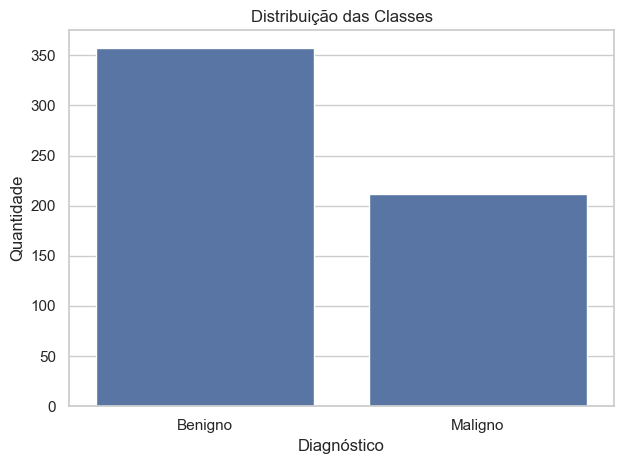

In [23]:
# Contagem de amostras por classe (Benigno = 0, Maligno = 1)
sns.countplot(x='diagnosis', data=wisconsin_base)
plt.title('Distribuição das Classes')
plt.xticks([0, 1], target_names)
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

### 4.3 Histogramas dos Atributos

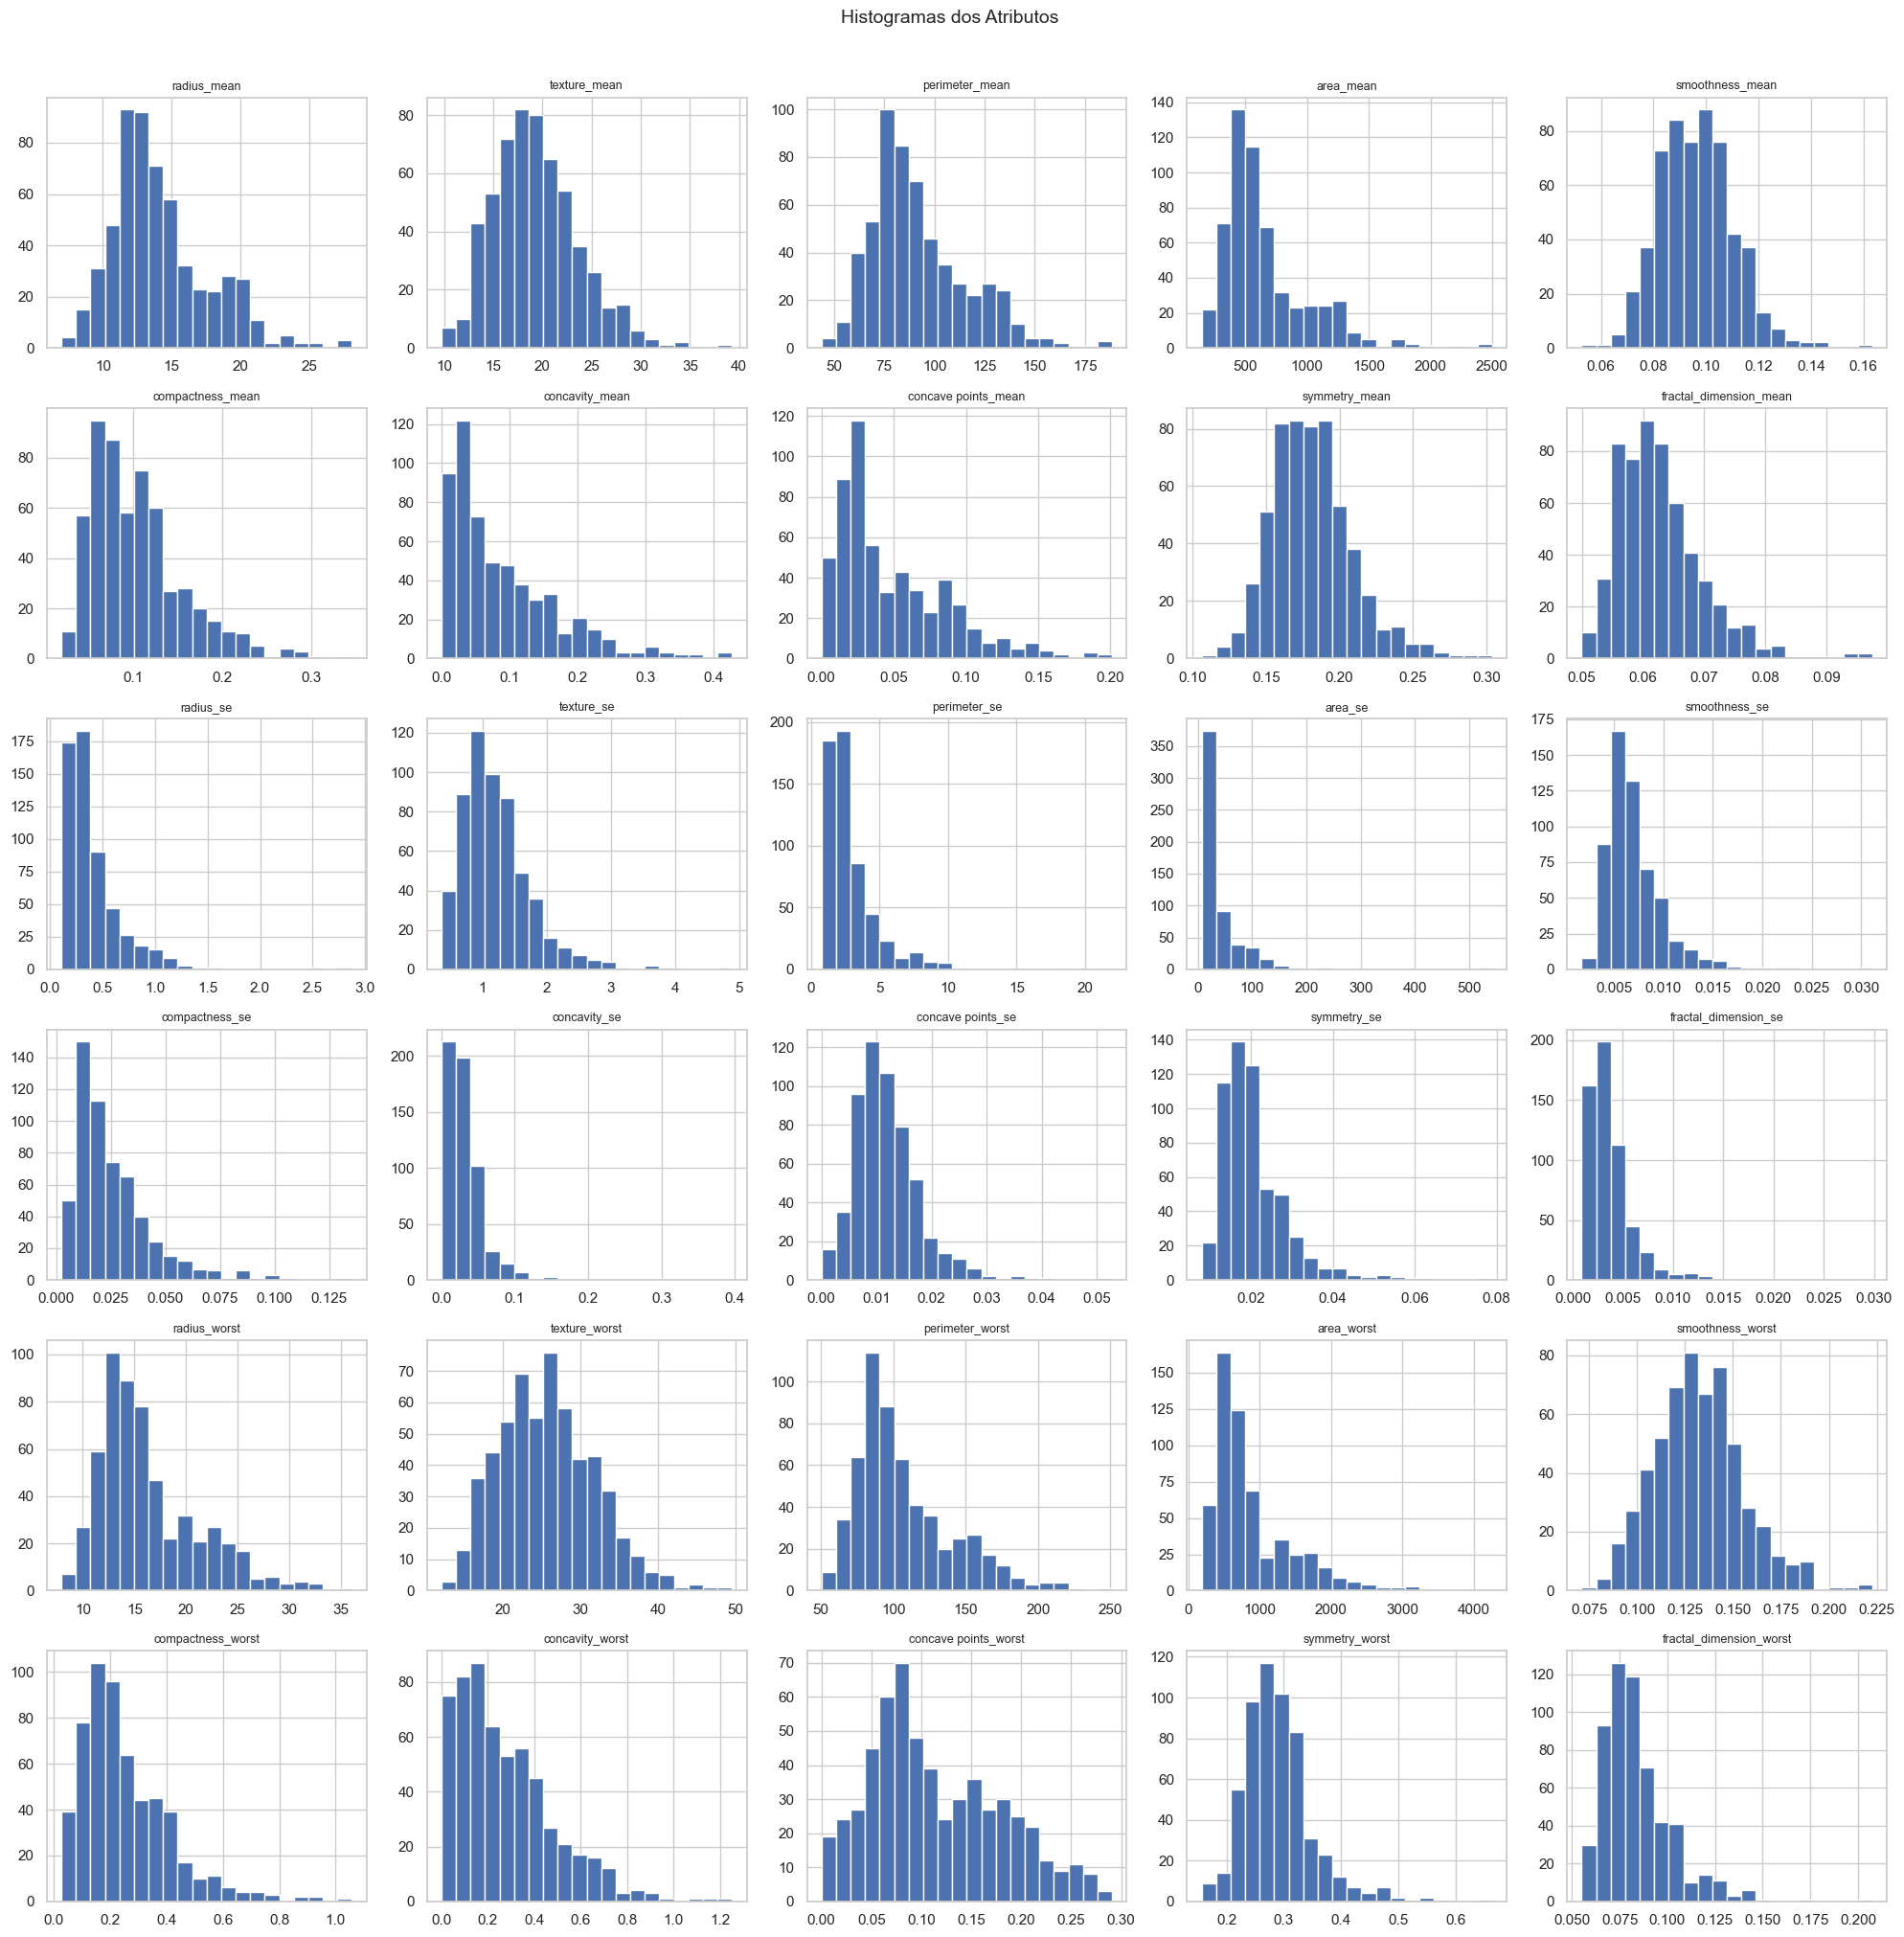

In [24]:
# Histograma de cada um dos 30 atributos numéricos
cols = wisconsin_base.columns[1:31]

fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(wisconsin_base[col], bins=20)
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Histogramas dos Atributos', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 4.4 Boxplots dos Atributos

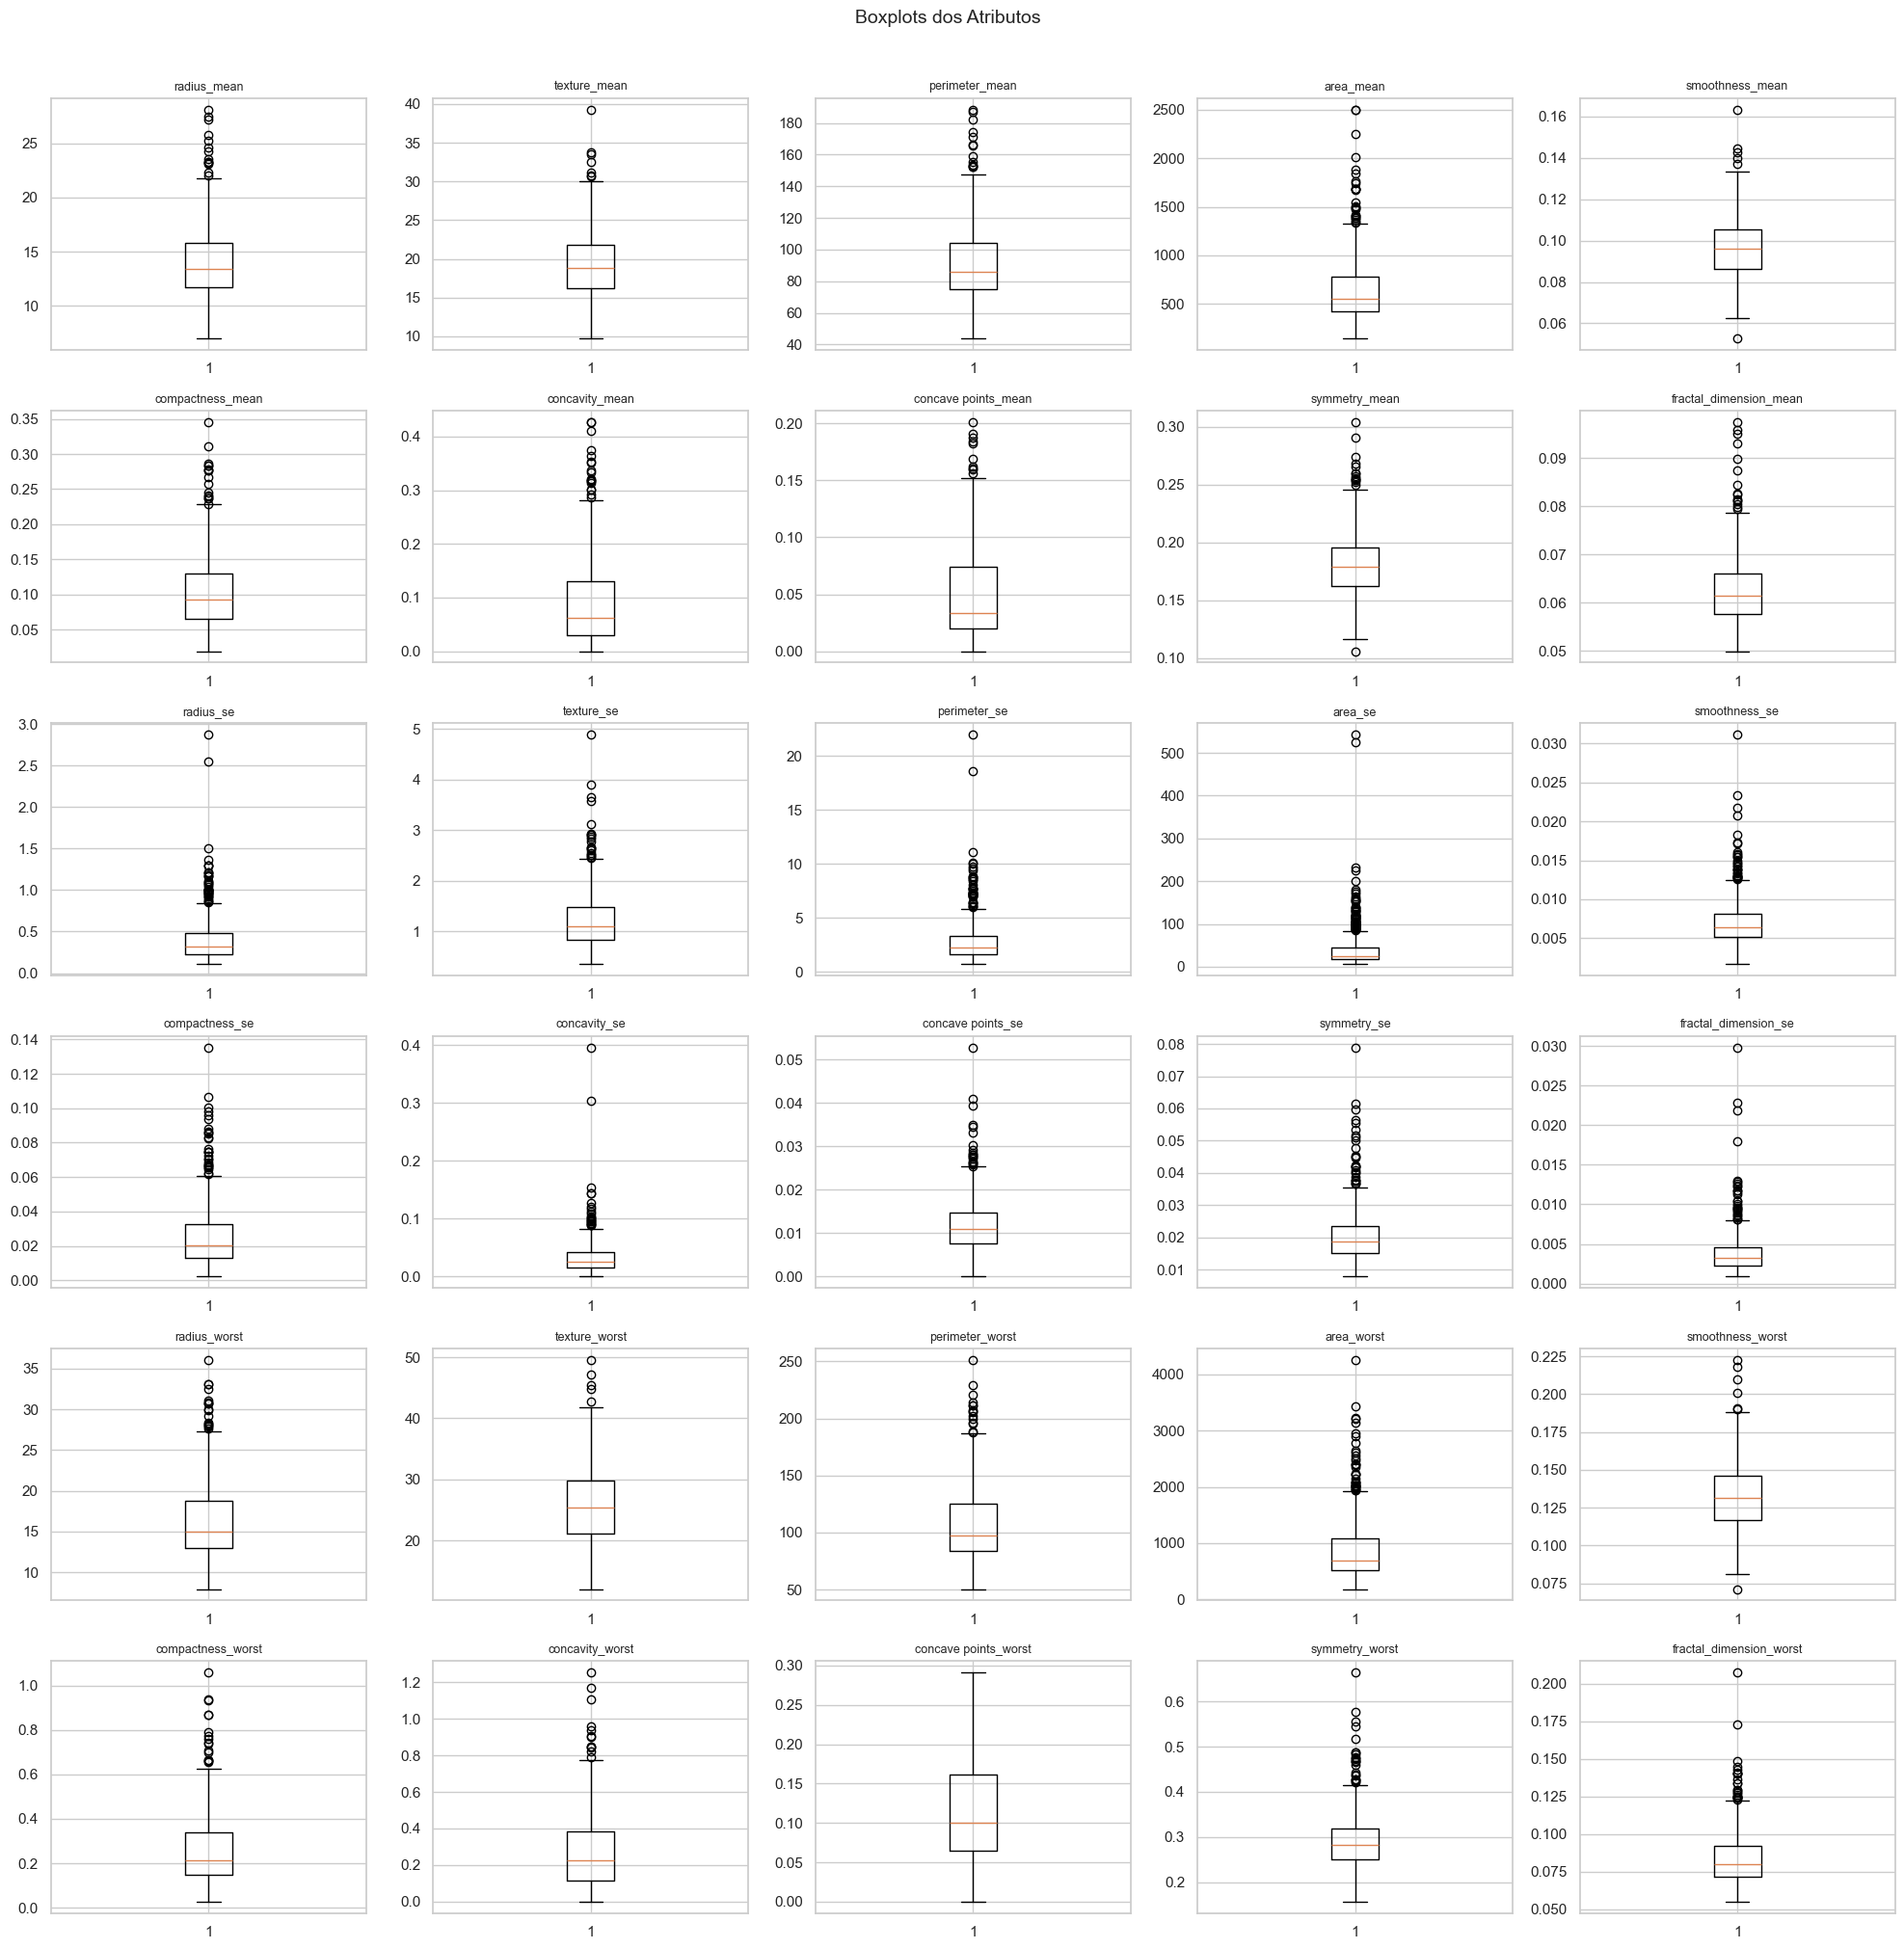

In [25]:
# Boxplots para identificar outliers e dispersão de cada atributo
cols = wisconsin_base.columns[1:31]

fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(wisconsin_base[col])
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Boxplots dos Atributos', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 5. Árvore de Decisão — Baseline

> **Nota:** esta seção usa os conjuntos `x_wisconsin_train` / `x_wisconsin_test` gerados com `test_size=0.2` (split legado para compatibilidade com código anterior). A partir da Seção 6, todos os modelos utilizam `X_train_scaled` / `X_test_scaled` (split padronizado com `test_size=0.25` e padronização Z-score).

In [11]:
# Divisão legada: 80 % treino | 20 % teste (sem padronização)
# Mantida para preservar os resultados originais da Árvore de Decisão
x_wisconsin = X.values
y_wisconsin = y.values

x_wisconsin_train, x_wisconsin_test, y_wisconsin_train, y_wisconsin_test = train_test_split(
    x_wisconsin, y_wisconsin, test_size=0.2, random_state=RANDOM_STATE
)

In [12]:
# Treinamento da Árvore de Decisão com critério de entropia (ganho de informação)
wisconsin_decision_tree = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE)
wisconsin_decision_tree.fit(x_wisconsin_train, y_wisconsin_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [13]:
# Importância de cada atributo segundo a árvore treinada
# (baseada na redução total de impureza ponderada por cada feature)
df_importancias = pd.DataFrame({
    'Atributo'   : feature_names,
    'Importância': wisconsin_decision_tree.feature_importances_,
}).sort_values('Importância', ascending=False).reset_index(drop=True)

display(df_importancias)

,Atributo,Importância
0,concave points_mean,0.593536
1,texture_worst,0.110206
2,perimeter_worst,0.105379
3,radius_worst,0.092874
4,concave points_worst,0.022002
5,area_se,0.021612
6,concave points_se,0.018594
7,perimeter_mean,0.012857
8,perimeter_se,0.009085
9,texture_mean,0.007494


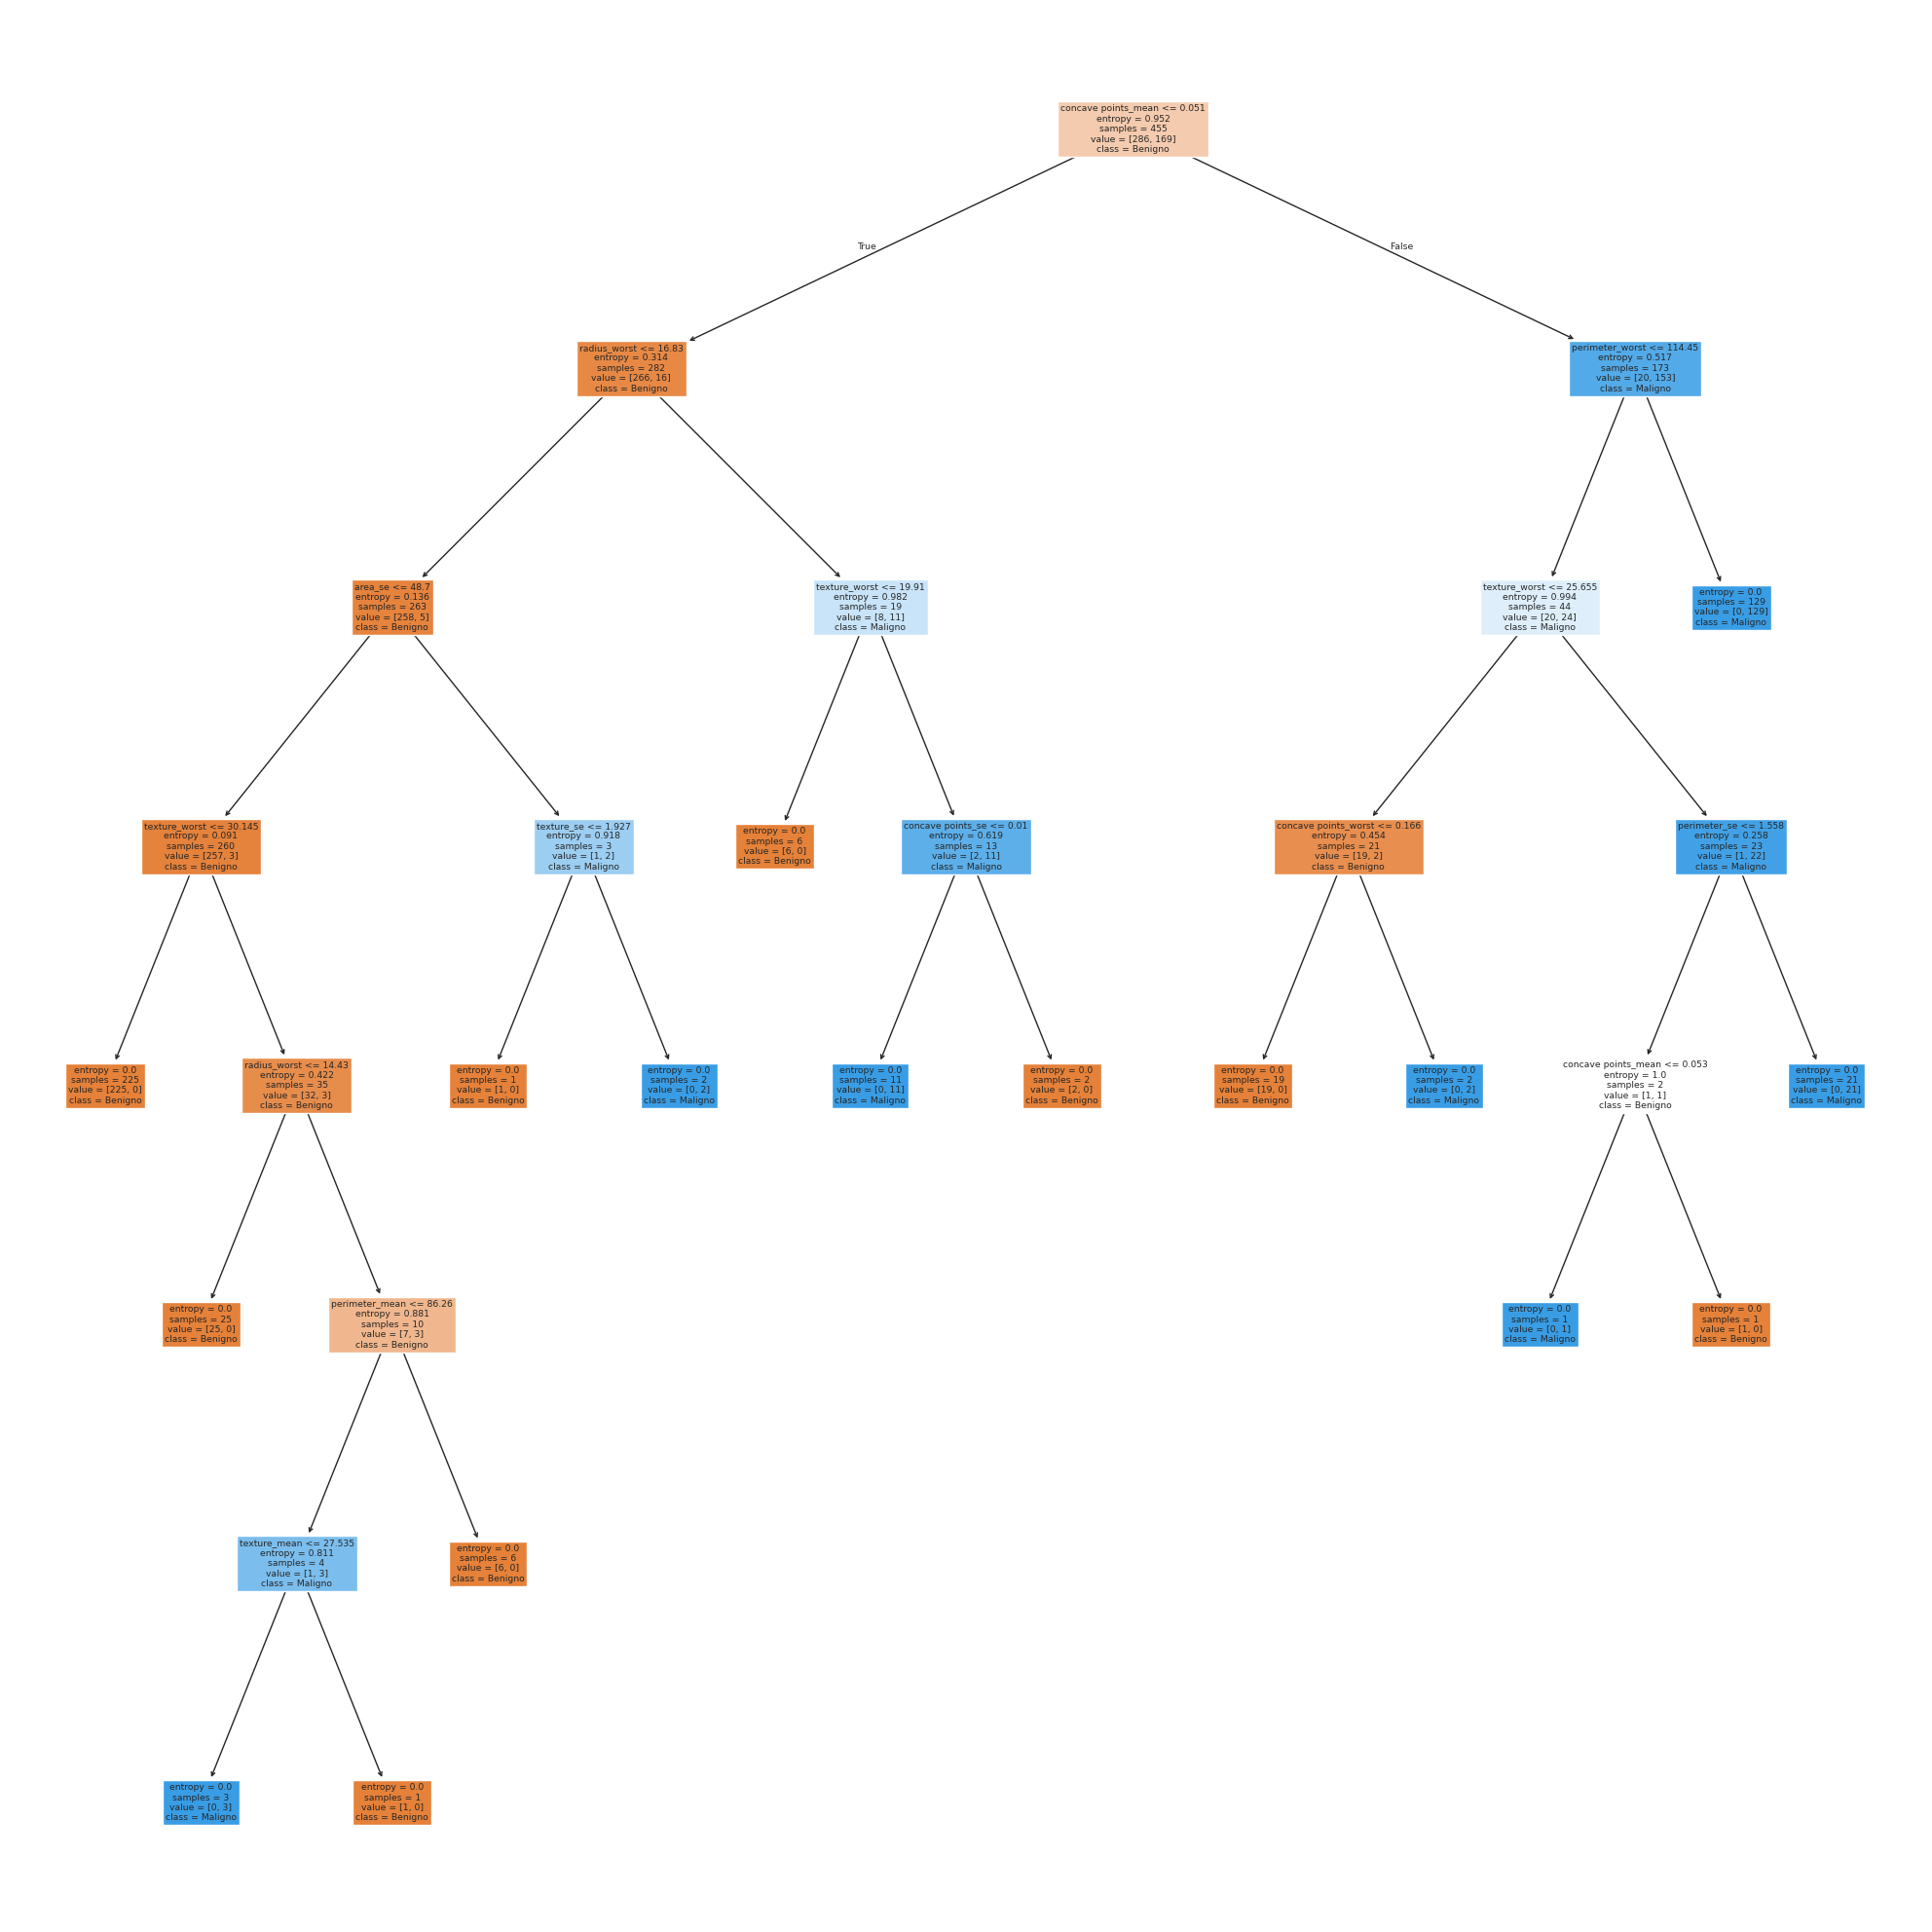

In [14]:
# Visualização gráfica da árvore de decisão
# filled=True colore os nós de acordo com a classe majoritária
fig, ax = plt.subplots(figsize=(20, 20))
tree.plot_tree(
    wisconsin_decision_tree,
    feature_names=feature_names,
    class_names=['Benigno', 'Maligno'],
    filled=True,
    ax=ax,
)
plt.tight_layout()
plt.show()

In [15]:
# Avaliação da Árvore de Decisão no conjunto de teste
previsao_dt = wisconsin_decision_tree.predict(x_wisconsin_test)

print('=== Árvore de Decisão — Relatório de Classificação ===')
print(classification_report(y_wisconsin_test, previsao_dt, target_names=target_names))

=== Árvore de Decisão — Relatório de Classificação ===
              precision    recall  f1-score   support

     Benigno       0.93      0.99      0.96        71
     Maligno       0.97      0.88      0.93        43

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



## 6. K-Nearest Neighbors KNN

> Nota: O KNN é altamente sensível à escala dos dados, portanto, OBRIGATORIAMENTE usamos a versão padronizada (`X_train_scaled` e `X_test_scaled`).

In [24]:
# Instanciando classe e definindo quantidade de vizinhos 
wisconsin_knn = KNeighborsClassifier(n_neighbors=20, weights='uniform')

In [25]:
# Treinando o modelo
wisconsin_knn.fit(X_train_scaled, y_train)

# Gerando as previsões e probabilidades no conjunto de teste
y_pred_knn = wisconsin_knn.predict(X_test_scaled)
y_prob_knn = wisconsin_knn.predict_proba(X_test_scaled)[:, 1]

--- Desempenho do Modelo KNN (k=20) ---


,Accuracy,Sensitivity (Recall+),Specificity (Recall-),F1,ROC-AUC,PR-AUC
0,0.958042,0.886792,1.0,0.94,0.997379,0.995144


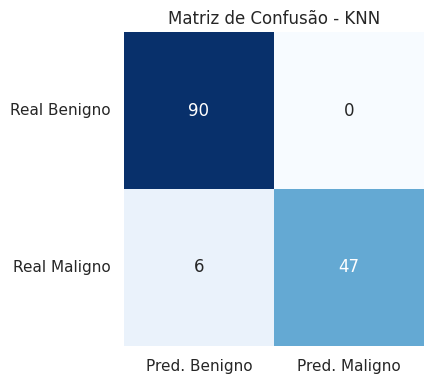

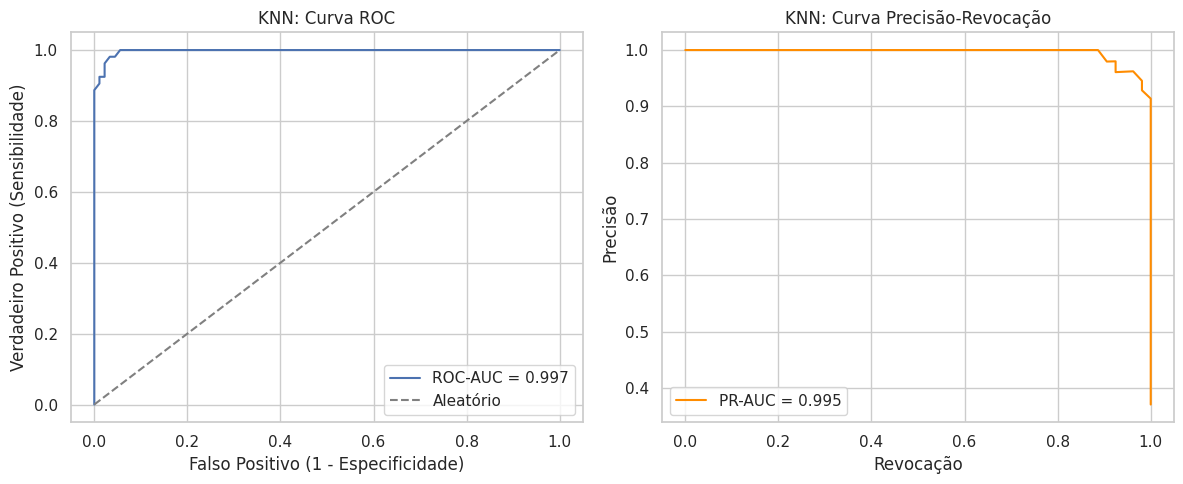

In [33]:
# Avaliação de Desempenho usando suas funções auxiliares
print("--- Desempenho do Modelo KNN (k=20) ---")
stats_knn = compute_stats(y_test, y_pred_knn, y_prob_knn)
display(pd.DataFrame([stats_knn]))

# Plotando as matrizes e curvas
plot_confusion(y_test, y_pred_knn, labels=('Benigno', 'Maligno'), titulo='Matriz de Confusão - KNN')
plot_roc_pr(y_test, y_prob_knn, titulo_prefixo='KNN: ')

## 7. Regressão Logística

=== Regressão Logística ===
              precision    recall  f1-score   support

     Benigno       0.97      0.99      0.98        90
     Maligno       0.98      0.94      0.96        53

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



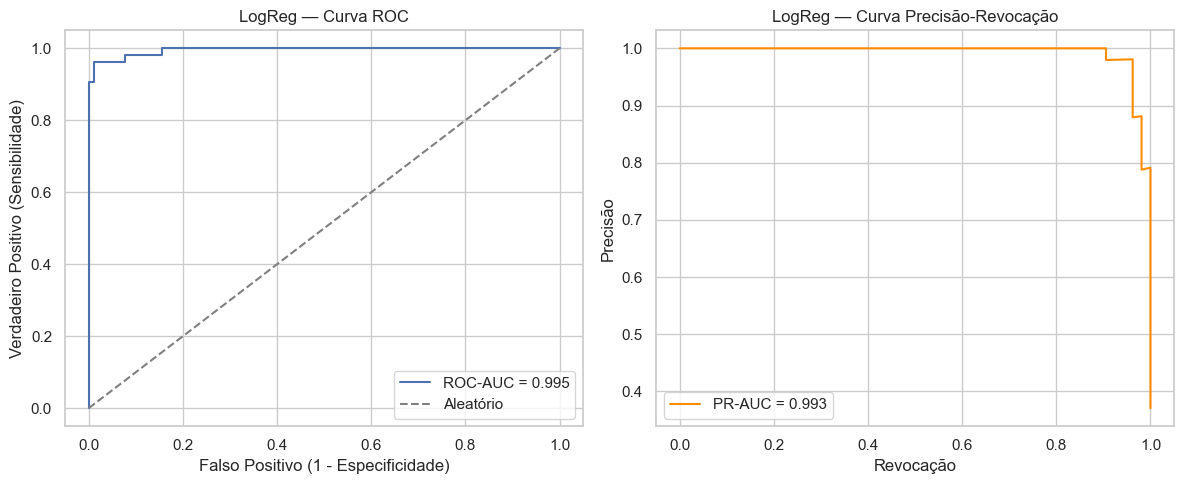

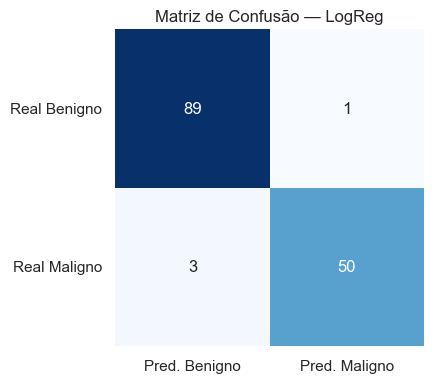

In [31]:
# --- Regressão Logística ---
# solver='lbfgs': eficiente para bases de tamanho médio
# max_iter elevado evita não-convergência; class_weight='balanced' penaliza erros na classe minoritária
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', solver='lbfgs', random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]  # P(Maligno)
pred_lr  = (proba_lr >= 0.5).astype(int)

print('=== Regressão Logística ===')
print(classification_report(y_test, pred_lr, target_names=target_names))
plot_roc_pr(y_test, proba_lr, titulo_prefixo='LogReg — ')
plot_confusion(y_test, pred_lr, titulo='Matriz de Confusão — LogReg')

## 8. Random Forest

=== Random Forest ===
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        90
     Maligno       1.00      0.92      0.96        53

    accuracy                           0.97       143
   macro avg       0.98      0.96      0.97       143
weighted avg       0.97      0.97      0.97       143



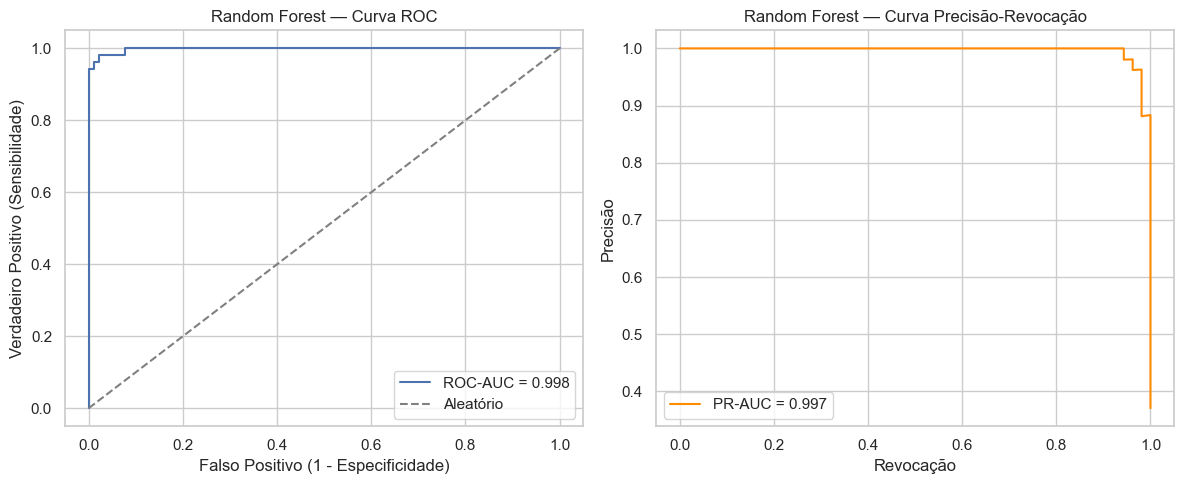

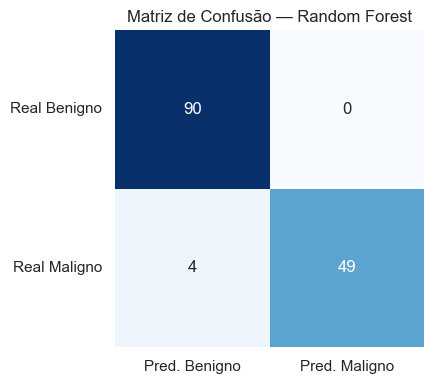

In [32]:
# --- Random Forest ---
# n_estimators=500: conjunto grande para estimativas estáveis; n_jobs=-1 usa todos os núcleos
rf = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1)
rf.fit(X_train_scaled, y_train)
proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
pred_rf  = (proba_rf >= 0.5).astype(int)

print('=== Random Forest ===')
print(classification_report(y_test, pred_rf, target_names=target_names))
plot_roc_pr(y_test, proba_rf, titulo_prefixo='Random Forest — ')
plot_confusion(y_test, pred_rf, titulo='Matriz de Confusão — Random Forest')

## 9. SVM (Support Vector Machine)

=== SVM (kernel RBF) ===
              precision    recall  f1-score   support

     Benigno       0.99      1.00      0.99        90
     Maligno       1.00      0.98      0.99        53

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



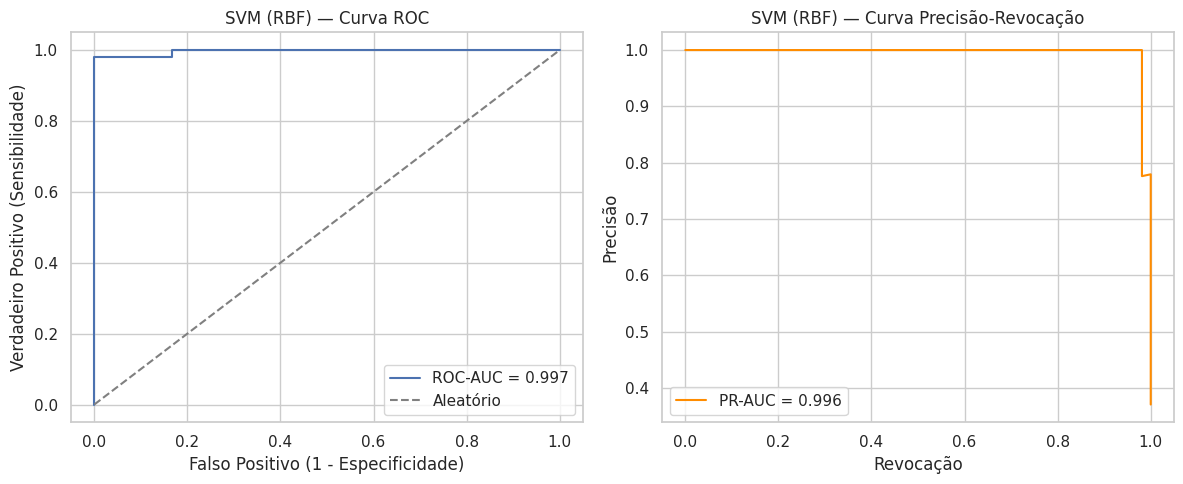

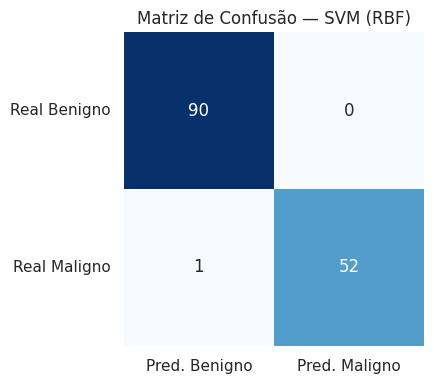

In [34]:
# --- SVM com kernel RBF ---
# kernel='rbf': captura fronteiras de decisão não-lineares
# probability=True habilita predict_proba (necessário para curvas ROC/PR)
svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
svm.fit(X_train_scaled, y_train)
proba_svm = svm.predict_proba(X_test_scaled)[:, 1]
pred_svm  = (proba_svm >= 0.5).astype(int)

print('=== SVM (kernel RBF) ===')
print(classification_report(y_test, pred_svm, target_names=target_names))
plot_roc_pr(y_test, proba_svm, titulo_prefixo='SVM (RBF) — ')
plot_confusion(y_test, pred_svm, titulo='Matriz de Confusão — SVM (RBF)')

## 10. Visualização de Estrutura: UMAP e PCA

/home/gabast/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


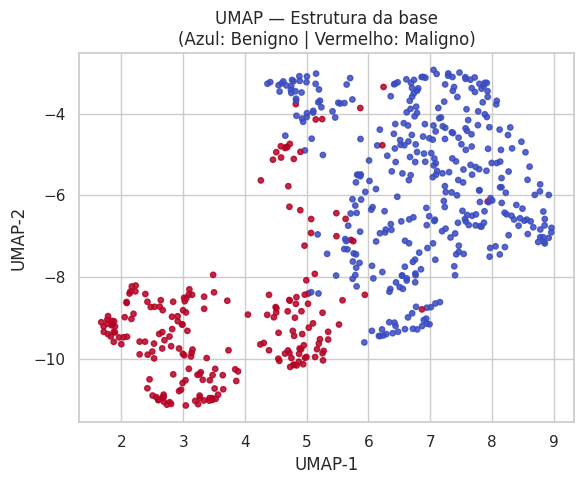

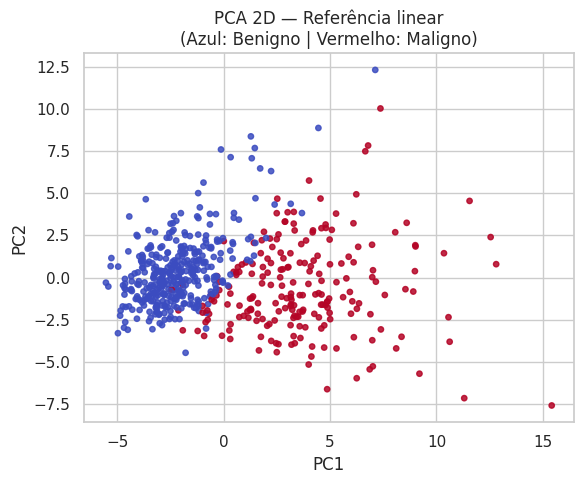

In [35]:
# ==============================================================================
# Técnicas de redução de dimensionalidade para visualização 2D da base completa.
# Ambas recebem X_scaled_all (todos os 569 pacientes, padronizados).
# ==============================================================================

# --- 10.1 UMAP (Uniform Manifold Approximation and Projection) ---
# Captura agrupamentos locais complexos (não-linear)
# n_neighbors: controla o balanço entre estrutura local e global
# min_dist:    distância mínima entre pontos no espaço 2D
reducer = umap.UMAP(random_state=RANDOM_STATE, n_neighbors=15, min_dist=0.1)
emb_umap = reducer.fit_transform(X_scaled_all)

plt.figure(figsize=(6, 5))
plt.scatter(emb_umap[:, 0], emb_umap[:, 1], c=y, cmap='coolwarm', s=15, alpha=0.85)
plt.title('UMAP — Estrutura da base\n(Azul: Benigno | Vermelho: Maligno)')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.tight_layout()
plt.show()

# --- 10.2 PCA (Principal Component Analysis) ---
# Redução linear para comparação com o UMAP
pca_emb = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled_all)

plt.figure(figsize=(6, 5))
plt.scatter(pca_emb[:, 0], pca_emb[:, 1], c=y, cmap='coolwarm', s=15, alpha=0.85)
plt.title('PCA 2D — Referência linear\n(Azul: Benigno | Vermelho: Maligno)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

## 11. Interpretabilidade do Modelo com SHAP

 99%|===================| 1129/1138 [01:16<00:00]        

=== Importância Global dos Atributos (SHAP Summary Plot) ===


/tmp/ipykernel_86586/2234863635.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_scaled_all, feature_names=feature_names)
/home/gabast/.local/lib/python3.11/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/home/gabast/.local/lib/python3.11/site-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


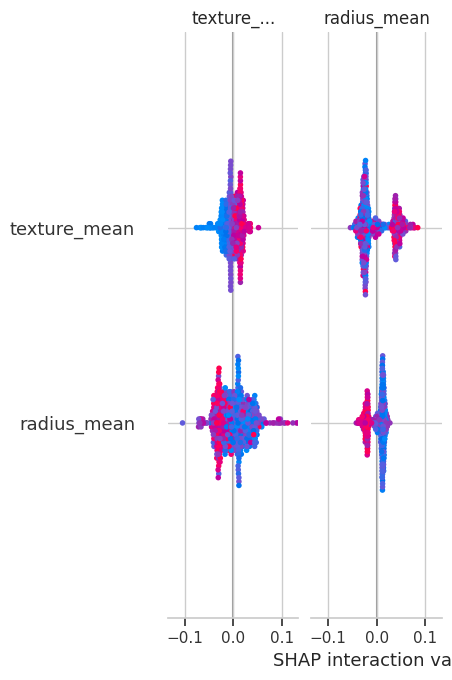


Probabilidade prevista de tumor maligno para o paciente 0: 97.0 %
=== Explicação Local — Waterfall Plot ===


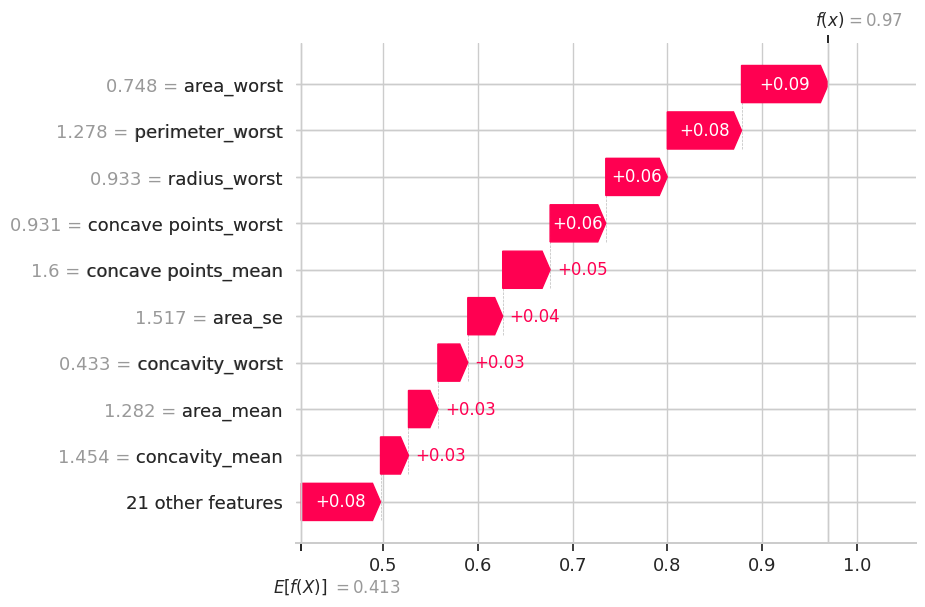

In [36]:
# ==============================================================================
# SHAP (SHapley Additive exPlanations) quantifica a contribuição de cada
# atributo para cada previsão individual do modelo.
#
# O Random Forest é retreinado com TODA a base (X_scaled_all) para obter
# explicações globais mais representativas.
# ==============================================================================

# --- 11.1 Treinamento do modelo explicável (base completa) ---
rf_all = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1,
).fit(X_scaled_all, y)

# --- 11.2 Cálculo dos valores SHAP ---
explainer   = shap.Explainer(rf_all, X_scaled_all)
shap_values = explainer(X_scaled_all)

# --- 11.3 Importância global: summary plot ---
# Exibe quais atributos mais influenciam as previsões (positiva ou negativamente)
print('=== Importância Global dos Atributos (SHAP Summary Plot) ===')
shap.summary_plot(shap_values, X_scaled_all, feature_names=feature_names)

# --- 11.4 Explicação local: exemplo de um paciente ---
# Waterfall plot mostrando como cada atributo empurrou a previsão
# para Benigno ou Maligno para um paciente específico do teste
idx = 0   # Índice do paciente no conjunto de teste
x0  = X_test_scaled[idx:idx + 1]
sv0 = explainer(x0)

prob_maligno = round(rf_all.predict_proba(x0)[0, 1] * 100, 2)
print(f'\nProbabilidade prevista de tumor maligno para o paciente {idx}: {prob_maligno} %')

# Foca na classe 1 (Maligno) — valores SHAP relativos à probabilidade de malignidade
single_explanation = shap.Explanation(
    values       = sv0.values[0, :, 1],
    base_values  = sv0.base_values[0, 1],
    data         = sv0.data[0],
    feature_names= feature_names,
)
print('=== Explicação Local — Waterfall Plot ===')
shap.plots.waterfall(single_explanation)